In [4]:
import os
print(os.getcwd())

/home/cap/capstone_design_2026/notebooks


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.decomposition import PCA

In [9]:
emb_dir = Path("../../data/processed/embeddings")
vecs = np.array([np.load(f) for f in sorted(emb_dir.glob("*.npy"))])
print(f"shape: {vecs.shape}")

shape: (176962, 1024)


95% variance: 9d
99% variance: 19d


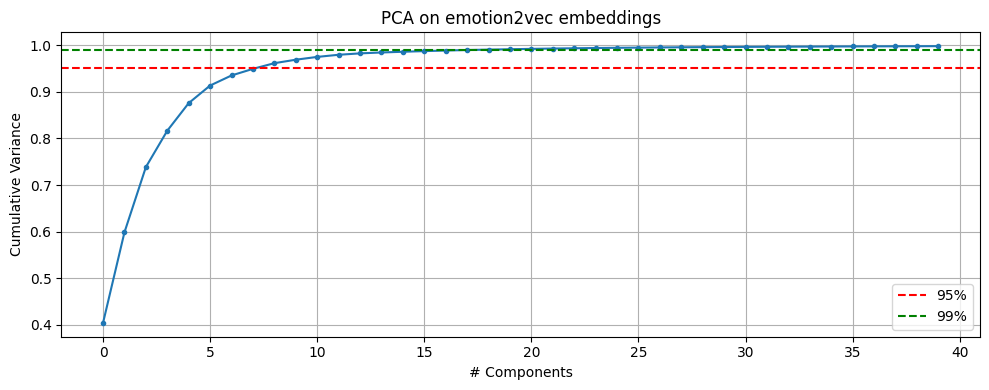

In [12]:
pca = PCA().fit(vecs)
cumvar = np.cumsum(pca.explained_variance_ratio_)

d95 = np.searchsorted(cumvar, 0.95) + 1
d99 = np.searchsorted(cumvar, 0.99) + 1
print(f"95% variance: {d95}d")
print(f"99% variance: {d99}d")

plt.figure(figsize=(10, 4))
plt.plot(cumvar[:40], marker='o', markersize=3)
plt.axhline(y=0.95, color='r', linestyle='--', label='95%')
plt.axhline(y=0.99, color='g', linestyle='--', label='99%')
plt.xlabel("# Components")
plt.ylabel("Cumulative Variance")
plt.title("PCA on emotion2vec embeddings")
plt.legend()
plt.grid(True)
plt.tight_layout()
#plt.savefig("pca_variance.png", dpi=150)
plt.show()